# How high can the `z` cutoff go before a mitosis is lost?

**Purpose.** `tm_threshold_axis_sweep_largest_cc.ipynb` (below: *lcc*) runs the click-seeded
`TM_CCOEFF` search with largest-CC size-tightening and reports every metric at
`CURRENT_Z = 1.0`. Its own recall grid shows `full_list_recall == 1.0` at every `z <= 1.5`
in all seven domains, and never below 1.0 anywhere in the grid for `201.tiff`, `094.tiff`
and `402.tiff` -- so the operating point is nowhere near the constraint. This notebook
re-runs the identical sweep and asks the question lcc's grid can only bracket: **for each
domain, what is the exact highest cutoff that still keeps every mitotic figure the search
finds at all, and what does moving there actually buy?**

**The answer needs no grid search.** lcc already computes it and throws it away (cell 38's
`tp_z_min`, used only as the `frac_fp_in_tp_range` cut point and never printed). The
argument, in four steps:

1. `pool` is **already score-descending** when it is built. `template_match.extract_peaks`
   returns a globally lexsorted list (`np.lexsort((ys, xs, -scores))`), `nms.nms_by_distance`
   preserves that ordering (`np.argsort(-scores, kind="stable")` over an already-ordered
   array, and it returns the keeps best-first), and the `self_hit_radius` boolean mask
   preserves row order. Asserted directly in the main loop below, not assumed.
2. Each `tm_score` arm's candidate frame is `pool[pool['score'] >= cut]`, re-sorted stably by
   score in `compare._rank`. Given (1) that frame is **exactly a prefix** of the deep pool.
3. `evaluate.greedy_match` walks detections in rank order and claims each ground-truth point
   once. Matching a prefix is therefore literally the first *N* steps of matching the whole
   list -- no re-assignment, by construction (`evaluate.py`'s module docstring makes this the
   reason greedy matching was chosen: *"with one greedy pass every threshold is a truncation
   of the ranked list, so the curve is monotone by construction"*).
4. So `full_list_recall` at cutoff `z` is exactly
   `#{TP-bucketed detections in the deep pool with z >= cut} / n_gt_mitotic`.

Therefore **`z_max` = the lowest `z` among the deep pool's TP-bucketed detections**, exactly,
and inclusively (the cut is `score >= cut`, so the binding detection survives *at* `z_max`).
It is computed here in raw score units (`tp_score_min`) so no float round-trip through
`med + z*mad` can drop the binding candidate, with `z_max` reported alongside for reading.
Step 4 also requires the deep pool to reach full recall in the first place; that is measured
per domain, not assumed.

**What is held fixed.** Everything. Channel (`hematoxylin_od`), method (`TM_CCOEFF`), the
largest-CC tightening rule and its gates, the seed-draw rule and `SEED_INDEX = 0`, the two
border/NMS fixes (padding so the whole ROI is reachable; NMS at a decoupled 5.0 um radius),
`OD_PAD = 25` for the chromatin window, `DEEP_FLOOR_Z = -1.5`, `peak_min_distance = 7`,
`self_hit_radius = 5.0`, `Z_LEVELS`, and `CURRENT_Z = 1.0` as the *reference* operating point.
The only additions are three new arms per domain (at `z_max`, and a one-notch-higher control)
and the diagnostics below. Nothing that produced lcc's numbers has moved, so every shared
column is directly comparable to `results/tm_ccoeff_threshold_axis_sweep_largest_cc.csv`.

## Read this before reading any number below

* **Raising `z` does not reduce what a pathologist reads.** On the `tm_score` axis,
  `recall_at_budget` is *exactly* invariant across the whole z sweep wherever
  `n_detections >= budget` (a score-descending list's top-K cannot change when only
  lower-scoring entries are deleted), and `compare._read_depths` is a `searchsorted` into a
  prefix of the *same* `tp_cum` array, so every `read_*` is either identical or `NaN`. Both
  are demonstrated below rather than argued. What a higher cutoff buys is full-list
  precision, downstream compute over the candidate set, the `chromatin_od` arm's top-K
  (the one place z moves recall@K at all), and a **much stronger recall claim** -- see the
  coverage point next.
* **`coverage_frac` is reported at every operating point -- but it cannot rehabilitate a
  recall number that has no freedom to move.** `evaluate.py` requires it before any full-list
  number: *"a detection list long enough to tile the ROI answers 'is this annotation within
  the match radius of some detection?' by geometry rather than by evidence."* That guard bites
  on a threshold chosen *before* looking at the labels. It does **not** apply to
  `full_list_recall == 1.0` at `z_max`: `z_max` is *defined* as the lowest TP score, so full
  recall there is true by construction, at coverage 0.06 for exactly the same reason it is
  true at coverage 0.99. The informative quantity is `z_max` **itself** -- how far above the
  map's median the worst-ranked mitosis sits -- not the recall measured at it. Where the guard
  does bite is the **deployable** cutoff, and it is reported there: `z ~ 1.31` leaves coverage
  at 0.79-0.99, squarely the regime `evaluate.py` calls geometry rather than evidence.
* **`z_max` is fitted to each ROI's own labels.** It is an upper bound on the available
  headroom, **not a deployable threshold** -- at inference you do not know where the mitoses
  are. The deployable question is "what fixed `z` is safe across ROIs, domains and clicks",
  and that is answered with a margin, over seeds, in the last two sections.
* **`chromatin_od` is reported, never used to decide.** `DECISIONS.md` D5's standing
  constraint requires the 14 ROIs of `images/extra_valid/` for any run that ranks by a
  chromatin statistic, *including as a compared axis*. This notebook uses the same 7-ROI
  draw lcc used (D5 was written after lcc ran), so every `chromatin_od` number here is
  **non-decision-grade** and is labelled as such where it appears. The recommendation is
  made on `tm_score` alone.
* **Two corrections carried in from `Research Logs/2026-09-04-largest-cc-z-headroom-audit.md`.**
  (i) lcc's closing summary claims every `read_95_delta` is smaller than its own ROI's
  seed-to-seed SD; joined on `file_name` that is false for `459.tiff` (+1416 vs SD 1199) and
  `402.tiff` (-1547 vs SD 593). The "not measurable at this sample size" verdict still rests
  on the three seed-0 endpoint hits, which are unaffected. (ii) `pool_sorted` is built here
  with `kind='mergesort'`, matching `compare._rank` and `extract_peaks`' documented tie
  convention; lcc used pandas' default unstable quicksort for that one frame.

In [1]:
import time
NB_T0 = time.time()

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

from midog_utils import chromatin as cm
from midog_utils import channels as ch
from midog_utils import compare as cp
from midog_utils import dataset as ds
from midog_utils import evaluate as ev
from midog_utils import experiment as ex
from midog_utils import find_and_suppress as fs
from midog_utils import seed_selection as ss
from midog_utils import template_match as tm
from midog_utils.nms import nms_by_distance
from sklearn.neighbors import KDTree

pd.set_option('display.width', 220)
pd.set_option('display.max_columns', 40)
print('imports ok')

imports ok


## Configuration -- byte-identical to `tm_threshold_axis_sweep_largest_cc.ipynb`

Copied, not re-derived, so any difference in a shared column is a bug rather than a config
drift. `CURRENT_Z = 1.0` stays as the *reference* point every "vs. the current operating
point" comparison below is measured against; it is not what this notebook recommends.
`SEEDS` is the only genuinely new knob -- `compare.summarise`'s docstring
(*"Never report a single-seed number (Step 0 rule 5)"*) applies to a threshold more than to
anything else in this repo, since a threshold is a thing you ship.

In [2]:
CHANNEL = 'hematoxylin_od'
METHOD = cv2.TM_CCOEFF
PEAK_MIN_DISTANCE = 7
SEED_INDEX = 0
SELF_HIT_RADIUS = 5.0

Z_LEVELS = (-1.0, -0.5, 0.0, 0.5, 1.0, 1.5, 2.0, 2.5, 3.0)
CURRENT_Z = 1.0                          # lcc's operating point -- the reference, not the recommendation
DEEP_FLOOR_Z = min(Z_LEVELS) - 0.5
MAX_PEAKS = 2_000_000

NMS_RADIUS_UM = 5.0
MATCH_RADIUS_UM = ev.MIDOG_RADIUS_UM

BUDGETS = cp.BUDGETS
AXES = ('tm_score', 'chromatin_od')
AXIS_RANK_KEY = {'tm_score': 'score', 'chromatin_od': 'od'}

CFG = fs.FSConfig(channel=CHANNEL, base_size=tm.BASE_SIZE, scales=(1.0,),
                  n_angles=1, flips=(False,), peak_min_distance=PEAK_MIN_DISTANCE,
                  self_hit_radius=SELF_HIT_RADIUS)
BORDER = CFG.patch_size // 2   # 36
OTSU_WINDOW = tm.BASE_SIZE     # 51
LARGEST_CC_KW = dict(min_area=50, max_area_frac=0.85, min_solidity=0.5)
OD_PAD = tm.BASE_SIZE // 2     # 25 -- the chromatin window's own margin, independent of PAD

FP_SUBSAMPLE_CAP = 8000
RNG_SEED = 0

# NEW. The threshold is the deliverable, so it gets the 5-seed treatment f1_seed_sweep.py
# uses, with the identical draw rule: np.random.default_rng([seed_index, image_id]) over the
# full border-filtered agreement pool, with draw_seed_with_retry on largest_cc_box.
SEEDS = tuple(range(5))
# Candidate count as a function of the cutoff, recorded per (domain, seed) so that the volume
# saved by ANY proposed threshold -- including the worst-over-seeds one, which is not on
# Z_LEVELS -- is answerable from the saved CSVs without re-running the sweep.
Z_DENSE = tuple(np.round(np.arange(0.0, 6.001, 0.05), 2))

BUCKET_COLOR = {ev.HUMAN_CORRECT_LABEL: '#2ca02c',
                ev.HUMAN_REJECTED_LABEL: '#ff7f0e',
                ev.NON_HUMAN_FINDINGS: '#7f7f7f'}
BUCKET_LANE = {ev.HUMAN_CORRECT_LABEL: 2, ev.HUMAN_REJECTED_LABEL: 1, ev.NON_HUMAN_FINDINGS: 0}
STYLE = {
    ev.NON_HUMAN_FINDINGS: dict(s=5, alpha=0.10, zorder=1),
    ev.HUMAN_REJECTED_LABEL: dict(s=10, alpha=0.35, zorder=2),
    ev.HUMAN_CORRECT_LABEL: dict(s=22, alpha=0.9, zorder=3, edgecolors='#145214', linewidths=0.3),
}
print('config ok')

config ok


## `largest_cc_box` and `draw_seed_with_retry` -- copied verbatim from lcc

Unchanged, including the synthetic retry test, so this notebook's seed draw is provably the
same one. (Still local to the notebook rather than in `midog_utils/seed_selection.py`, for
lcc's reason: this rule was historically probed and explicitly *not* adopted as production
logic -- `Research Logs/2026-08-25-bbox-tuning-domain-mismatch.md`, Experiment 5.)

In [3]:
def _odd_local(n: int, minimum: int = 5) -> int:
    n = int(round(n))
    if n % 2 == 0:
        n += 1
    return max(minimum, n)


def largest_cc_box(patch, min_area=50, max_area_frac=0.85, min_solidity=0.5):
    '''Otsu-threshold `patch` and return the bbox of its LARGEST connected component by area,
    regardless of whether it contains the click. (y0, y1, x0, x1), patch-local, half-open,
    or None. Mirrors seed_selection.tighten_box_otsu's "binary" path with only the
    component-selection step changed.'''
    if patch.ndim != 2:
        raise ValueError(f"largest_cc_box needs a single-channel patch, got shape {patch.shape}")
    u8 = cv2.normalize(patch.astype(np.float32), None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    _, binary = cv2.threshold(u8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    labels = label(binary, connectivity=2)
    regions = regionprops(labels)
    if not regions:
        return None
    largest = max(regions, key=lambda r: r.area)
    if largest.area < min_area:
        return None
    if largest.area > max_area_frac * patch.size:
        return None
    if largest.solidity < min_solidity:
        return None
    y0, x0, y1, x1 = largest.bbox
    return int(y0), int(y1), int(x0), int(x1)


def draw_seed_with_retry(pool: pd.DataFrame, rng, check_fn):
    '''Draw a row from `pool` via `rng.integers`; on failure, drop it and redraw, consuming
    the same rng stream. Returns (row, result, n_retries). Raises if the pool empties.'''
    working = pool.copy()
    retries = 0
    while len(working) > 0:
        idx = int(rng.integers(len(working)))
        row = working.iloc[idx]
        result = check_fn(row)
        if result is not None:
            return row, result, retries
        working = working.drop(working.index[idx])
        retries += 1
    raise ValueError("seed pool exhausted -- no candidate passed check_fn after all retries")


class _StubRNG:
    def integers(self, n):
        return 0


fake_pool = pd.DataFrame({'val': [10, 20, 30]}, index=[100, 101, 102])
row, result, retries = draw_seed_with_retry(
    fake_pool, _StubRNG(), lambda r: None if r['val'] == 10 else r['val'])
assert (row['val'], result, retries) == (20, 20, 1), 'retry path regressed'
try:
    draw_seed_with_retry(pd.DataFrame({'val': [1, 2]}), _StubRNG(), lambda r: None)
    raise AssertionError('expected ValueError on pool exhaustion')
except ValueError:
    pass
print('largest_cc_box / draw_seed_with_retry defined; both synthetic retry paths pass')

largest_cc_box / draw_seed_with_retry defined; both synthetic retry paths pass


## One ROI per domain -- the same seven

In [4]:
images, annotations = ds.load_annotations()
ds.check_invariants(annotations)
domain_images = ex.select_domain_images(images, annotations, images_dir='images')
domain_images = domain_images.sort_values('tumor_type').reset_index(drop=True)

_rows = []
for _, r in domain_images.iterrows():
    mpp = ds.roi_mpp(f"images/{r['file_name']}")
    _rows.append({'tumor_type': r['tumor_type'], 'file_name': r['file_name'],
                  'n_mitotic': r['n_mitotic'], 'mpp': round(mpp, 4),
                  'match_radius_px': round(ev.radius_px(mpp, MATCH_RADIUS_UM), 2),
                  'nms_radius_px': round(ev.radius_px(mpp, NMS_RADIUS_UM), 2)})
pd.DataFrame(_rows)

,tumor_type,file_name,n_mitotic,mpp,match_radius_px,nms_radius_px
0,canine cutaneous mast cell tumor,301.tiff,218,0.2533,29.61,19.74
1,canine lung cancer,201.tiff,18,0.2482,30.22,20.15
2,canine lymphosarcoma,246.tiff,116,0.2482,30.22,20.15
3,canine soft tissue sarcoma,459.tiff,131,0.2482,30.22,20.15
4,human breast cancer,094.tiff,82,0.2298,32.63,21.75
5,human melanoma,548.tiff,239,0.2274,32.98,21.98
6,human neuroendocrine tumor,402.tiff,105,0.2263,33.14,22.09


## Main sweep

One deep pool per domain per seed, built exactly as lcc's. For **seed 0** the full arm set is
evaluated: lcc's `Z_LEVELS` grid on both axes (so every shared column reproduces lcc's CSV),
plus three new arms --

* `tm_score@zmax` / `chromatin_od@zmax` -- cut at `score >= tp_score_min`, the exact highest
  cutoff that keeps every TP;
* `tm_score@zmax_strict` -- cut at `score > tp_score_min`, i.e. **one notch higher**, which
  must lose exactly the binding detection. This is the control that turns the closed-form
  argument into a measurement: recall must be 1.0 in the first and below 1.0 in the second.

For **seeds 1-4** only the deep pool and its `tp_score_min` are computed (no arms, no
coverage), because that is all the robustness section needs and it keeps the run under ~10
minutes. The ROI is loaded once per domain and reused across its five seeds.

In [5]:
all_rows, seed_rows, tpz_rows, checks_rows, vol_rows = [], [], [], [], []
kept_pools, kept_gt, roi_meta = {}, {}, {}   # every seed's pool, so the deployable cutoffs
                                             # below can be EVALUATED rather than interpolated
pools = {}          # fn -> seed-0 bucketed detection frame (score-descending)
gt_by_file = {}     # fn -> seed-0 gt_eval, for the unanimity split below
import gc

for _, row in domain_images.iterrows():
    fn, image_id, domain = row['file_name'], int(row['image_id']), row['tumor_type']
    t_dom = time.time()

    rgb = ds.load_roi(f'images/{fn}')
    mpp = ds.roi_mpp(f'images/{fn}')
    match_radius = ev.radius_px(mpp, MATCH_RADIUS_UM)
    nms_radius = ev.radius_px(mpp, NMS_RADIUS_UM)
    hem = ch.to_channel(rgb, CHANNEL)
    gray_inv = ch.to_gray_inverted(rgb)
    H, W = hem.shape[:2]
    roi_shape = rgb.shape
    gt = ds.image_annotations(annotations, fn)
    gt_mit = gt[gt['category_id'] == ds.MITOTIC]
    pool_seed, flagged = ss.agreement_pool(gt_mit)
    pool_seed = ss.border_filter(pool_seed, BORDER, roi_shape)
    del rgb
    gc.collect()

    def _check(cand_row, _gray_inv=gray_inv):
        _patch = tm.read_padded_patch(_gray_inv, float(cand_row['cx']), float(cand_row['cy']),
                                      OTSU_WINDOW)
        return None if _patch is None else largest_cc_box(_patch, **LARGEST_CC_KW)

    for si in SEEDS:
        t0 = time.time()
        rng = np.random.default_rng([si, image_id])
        seed, seed_box, n_retries = draw_seed_with_retry(pool_seed, rng, _check)
        seed_xy = (float(seed['cx']), float(seed['cy']))
        seed_ann_id = int(seed['ann_id'])
        y0, y1, x0, x1 = seed_box
        base_size = _odd_local(max(y1 - y0, x1 - x0), minimum=5)
        gt_eval = gt[gt['ann_id'] != seed_ann_id].reset_index(drop=True)

        patch73 = tm.read_padded_patch(hem, *seed_xy, CFG.patch_size)
        templates, _ = tm.build_augmentations(patch73, base_size, CFG.scales,
                                              CFG.n_angles, CFG.flips)
        PAD = max((t.shape[0] - 1) // 2 for t in templates)
        hem_p = cv2.copyMakeBorder(hem, PAD, PAD, PAD, PAD, borderType=cv2.BORDER_REPLICATE)
        fused_p, best_p, valid_p = tm.fused_response(hem_p, templates, CFG.scale_normalize,
                                                     method=METHOD)
        fused = fused_p[PAD:PAD + H, PAD:PAD + W]
        valid = valid_p[PAD:PAD + H, PAD:PAD + W]
        assert bool(valid.all()), f'{fn} s{si}: padding did not make the whole ROI valid'
        del hem_p, fused_p, best_p, valid_p
        gc.collect()

        med, mad = tm.robust_stats(fused, valid)
        deep_floor = med + DEEP_FLOOR_Z * mad
        centers, scores = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, deep_floor, MAX_PEAKS)
        keep = nms_by_distance(centers, scores, nms_radius)
        centers, scores = centers[keep], scores[keep]
        ok = np.hypot(centers[:, 0] - seed_xy[0], centers[:, 1] - seed_xy[1]) > CFG.self_hit_radius
        centers, scores = centers[ok], scores[ok]

        pool = pd.DataFrame({'cx': centers[:, 0], 'cy': centers[:, 1], 'score': scores})
        pool['z'] = (pool['score'] - med) / mad

        # --- STEP 1 OF THE CLOSED FORM, ASSERTED: the pool is already score-descending, so a
        # score cut is a prefix and compare._rank cannot reorder it. Not assumed anywhere.
        already_sorted = bool(np.all(np.diff(pool['score'].to_numpy()) <= 0))
        assert already_sorted, f'{fn} s{si}: pool is not score-descending -- prefix argument void'

        od_naive_nan = int(cm.score_detections(pool[['cx', 'cy']].copy(), hem)['od'].isna().sum())
        hem_od_p = cv2.copyMakeBorder(hem, OD_PAD, OD_PAD, OD_PAD, OD_PAD,
                                      borderType=cv2.BORDER_REPLICATE)
        shifted = pool[['cx', 'cy']].assign(cx=pool['cx'] + OD_PAD, cy=pool['cy'] + OD_PAD)
        pool['od'] = cm.score_detections(shifted, hem_od_p)['od'].to_numpy()
        assert int(pool['od'].isna().sum()) == 0, f'{fn} s{si}: od still NaN after the padding fix'
        del hem_od_p
        gc.collect()

        # --- bucket the deep pool. mergesort (lcc used pandas' default quicksort here), so the
        # tie order matches compare._rank exactly and this frame IS the arms' ranking.
        pool_sorted = pool.sort_values('score', ascending=False,
                                       kind='mergesort').reset_index(drop=True)
        assert pool_sorted['score'].equals(pool['score']), \
            f'{fn} s{si}: stable re-sort changed the order of an already-sorted pool'
        det_out, gt_out = ev.bucket_detections(pool_sorted, gt_eval, match_radius)

        n_mit = int((gt_eval['category_id'] == ds.MITOTIC).sum())
        tp = det_out[det_out['bucket'] == ev.HUMAN_CORRECT_LABEL]
        deep_recall = len(tp) / n_mit
        tp_z_sorted = np.sort(tp['z'].to_numpy())
        tp_score_sorted = np.sort(tp['score'].to_numpy())
        tp_score_min = float(tp_score_sorted[0])
        z_max = float(tp_z_sorted[0])
        if deep_recall < 1.0:
            print(f"[{fn} s{si}] NOTE: deep pool recall is {deep_recall:.4f}, not 1.0 -- z_max is "
                  f"'keeps every mitosis this pool finds', not 'every mitosis'", flush=True)

        n_at_current = int((pool['score'] >= med + CURRENT_Z * mad).sum())
        n_at_zmax = int((pool['score'] >= tp_score_min).sum())
        seed_rows.append({
            'tumor_type': domain, 'file_name': fn, 'seed_index': si, 'seed_ann_id': seed_ann_id,
            'n_retries': n_retries, 'base_size': base_size, 'n_pool': len(pool),
            'n_gt_mitotic': n_mit, 'deep_recall': round(deep_recall, 4),
            'map_median': med, 'mad_scale': mad,
            'z_max': z_max,            # full precision, NEVER rounded: this is a minimum, and
            'tp_score_min': tp_score_min,   # round-to-nearest moves it UP in ~half of all cells,
                                            # which then drops the binding mitosis when used as a cut

            'n_at_current_z': n_at_current, 'n_at_z_max': n_at_zmax,
            'pct_pool_cut': round(100 * (1 - n_at_zmax / n_at_current), 2)})

        kept_pools[(fn, si)] = pool[['cx', 'cy', 'score', 'z', 'od']].copy()
        kept_gt[(fn, si)] = gt_eval
        roi_meta[fn] = {'mpp': mpp, 'match_radius': match_radius, 'roi_shape': roi_shape}

        for zz in Z_DENSE:
            vol_rows.append({'file_name': fn, 'tumor_type': domain, 'seed_index': si,
                             'z': float(zz),
                             'n_at_z': int((pool['score'] >= med + zz * mad).sum())})

        # every TP's z, kept for the order-statistics and unanimity sections
        for rk, (_, r_tp) in enumerate(tp.sort_values('z').iterrows()):
            tpz_rows.append({'file_name': fn, 'tumor_type': domain, 'seed_index': si,
                             'tp_rank_from_bottom': rk, 'z': float(r_tp['z']),
                             'score': float(r_tp['score']),
                             'matched_ann_id': int(r_tp['matched_ann_id'])})

        if si == SEED_INDEX:
            pools[fn] = det_out
            gt_by_file[fn] = gt_eval

            # one-match-many-z shortcut, re-verified at the NEW operating point as well
            for tag, cut in (('current_z', med + CURRENT_Z * mad), ('z_max', tp_score_min)):
                c2, s2 = tm.extract_peaks(fused, valid, PEAK_MIN_DISTANCE, cut, MAX_PEAKS)
                k2 = nms_by_distance(c2, s2, nms_radius)
                c2 = c2[k2]
                c2 = c2[np.hypot(c2[:, 0] - seed_xy[0], c2[:, 1] - seed_xy[1]) > CFG.self_hit_radius]
                filt = pool.loc[pool['score'] >= cut, ['cx', 'cy']].to_numpy()
                a = c2[np.lexsort((c2[:, 1], c2[:, 0]))] if len(c2) else c2
                b = filt[np.lexsort((filt[:, 1], filt[:, 0]))] if len(filt) else filt
                ok_sc = (a.shape == b.shape) and bool(np.allclose(a, b))
                assert ok_sc, f'{fn}: one-match-many-z shortcut failed at {tag}'
                checks_rows.append({'file_name': fn, 'domain': domain, 'check': f'shortcut@{tag}',
                                    'n_direct': len(c2), 'n_filtered': len(filt), 'passed': ok_sc})

            _dgt, _ = KDTree(gt_eval[['cx', 'cy']].to_numpy()).query(
                det_out[['cx', 'cy']].to_numpy(), k=1)
            checks_rows.append({'file_name': fn, 'domain': domain, 'check': 'dup_fp_deep_pool',
                                'n_direct': int(((_dgt[:, 0] <= match_radius) &
                                                 (det_out['bucket'] == ev.NON_HUMAN_FINDINGS)
                                                 .to_numpy()).sum()),
                                'n_filtered': len(det_out), 'passed': True})

            ctx = {'file_name': fn, 'image_id': image_id, 'tumor_type': domain,
                   'mpp': round(mpp, 4), 'seed_index': si, 'seed_ann_id': seed_ann_id,
                   'base_size': base_size, 'n_retries': n_retries,
                   'map_median': round(med, 5), 'mad_scale': round(mad, 5),
                   'deep_floor': round(deep_floor, 5), 'n_pool': len(pool),
                   'pad_px': PAD, 'nms_radius_px': round(nms_radius, 3),
                   'match_radius_px': round(match_radius, 3),
                   'z_max': z_max, 'deep_recall': round(deep_recall, 4)}

            arms = []
            for z in Z_LEVELS:
                cut = med + z * mad
                sub = pool[pool['score'] >= cut]
                for axis in AXES:
                    arms.append(cp.Arm(axis, (lambda d=sub: d), rank_key=AXIS_RANK_KEY[axis],
                                       seeded=True, z=z, z_dependent=True,
                                       floor_limited=bool(cut < deep_floor), nms_radius=None,
                                       caps=(MAX_PEAKS,),
                                       extra={'axis': axis, 'op_point': 'grid',
                                              'z_cut': round(cut, 5)}))
            sub_zmax = pool[pool['score'] >= tp_score_min]
            for axis in AXES:
                arms.append(cp.Arm(f'{axis}@zmax', (lambda d=sub_zmax: d),
                                   rank_key=AXIS_RANK_KEY[axis], seeded=True, z=round(z_max, 5),
                                   z_dependent=True, floor_limited=False, nms_radius=None,
                                   caps=(MAX_PEAKS,),
                                   extra={'axis': axis, 'op_point': 'zmax',
                                          'z_cut': tp_score_min}))
            sub_strict = pool[pool['score'] > tp_score_min]
            arms.append(cp.Arm('tm_score@zmax_strict', (lambda d=sub_strict: d),
                               rank_key='score', seeded=True, z=round(z_max, 5),
                               z_dependent=True, floor_limited=False, nms_radius=None,
                               caps=(MAX_PEAKS,),
                               extra={'axis': 'tm_score', 'op_point': 'zmax_strict',
                                      'z_cut': tp_score_min}))

            all_rows.append(cp.evaluate_arms(arms, gt_eval, match_radius, roi_shape=roi_shape,
                                             mpp=mpp, budgets=BUDGETS, context=ctx))

        print(f"[{fn}] s{si} base_size={base_size:2d} n_pool={len(pool):6d} TP={len(tp)}/{n_mit} "
              f"z_max={z_max:.3f} n(z=1.0)={n_at_current} -> n(z_max)={n_at_zmax} "
              f"({100 * (1 - n_at_zmax / n_at_current):4.1f}% cut) od_nan={od_naive_nan}->0 "
              f"[{time.time() - t0:.0f}s]", flush=True)

        del fused, valid, patch73, templates, pool, pool_sorted, det_out
        gc.collect()

    del hem, gray_inv, _check
    gc.collect()
    print(f"  -- {domain} done in {time.time() - t_dom:.0f}s", flush=True)

results = pd.concat(all_rows, ignore_index=True)
cp.assert_floor_not_limiting(results)
seed_df = pd.DataFrame(seed_rows)
tpz_df = pd.DataFrame(tpz_rows)
checks_df = pd.DataFrame(checks_rows)
vol_df = pd.DataFrame(vol_rows)
print(f"\ntotal {time.time() - NB_T0:.0f}s | {len(results)} arm rows | "
      f"{len(seed_df)} (domain, seed) cells | deep_recall == 1.0 in "
      f"{int((seed_df['deep_recall'] == 1.0).sum())}/{len(seed_df)}")

[301.tiff] s0 base_size=41 n_pool= 25447 TP=217/217 z_max=1.987 n(z=1.0)=22227 -> n(z_max)=15929 (28.3% cut) od_nan=659->0 [25s]


[301.tiff] s1 base_size=51 n_pool= 32225 TP=217/217 z_max=2.103 n(z=1.0)=29010 -> n(z_max)=15769 (45.6% cut) od_nan=797->0 [9s]


[301.tiff] s2 base_size=19 n_pool= 33716 TP=217/217 z_max=3.403 n(z=1.0)=29263 -> n(z_max)=10756 (63.2% cut) od_nan=816->0 [10s]


[301.tiff] s3 base_size=19 n_pool= 34274 TP=217/217 z_max=2.517 n(z=1.0)=31198 -> n(z_max)=15692 (49.7% cut) od_nan=840->0 [13s]


[301.tiff] s4 base_size=27 n_pool= 30382 TP=217/217 z_max=1.666 n(z=1.0)=25978 -> n(z_max)=22143 (14.8% cut) od_nan=802->0 [15s]


...

[402.tiff] s2 base_size=51 n_pool= 29723 TP=104/104 z_max=1.919 n(z=1.0)=22098 -> n(z_max)=10028 (54.6% cut) od_nan=690->0 [13s]


[402.tiff] s3 base_size=31 n_pool= 31042 TP=104/104 z_max=2.626 n(z=1.0)=25248 -> n(z_max)=7683 (69.6% cut) od_nan=754->0 [12s]


[402.tiff] s4 base_size=27 n_pool= 33966 TP=104/104 z_max=2.488 n(z=1.0)=29103 -> n(z_max)=10907 (62.5% cut) od_nan=762->0 [15s]


  -- human neuroendocrine tumor done in 101s



total 600s | 1176 arm rows | 35 (domain, seed) cells | deep_recall == 1.0 in 35/35


## Persist the run

In [6]:
import pathlib
pathlib.Path('results').mkdir(exist_ok=True)
results.to_csv('results/tm_ccoeff_threshold_axis_sweep_largest_cc_high_z.csv', index=False)
seed_df.to_csv('results/tm_ccoeff_high_z_seed_table.csv', index=False)
tpz_df.to_csv('results/tm_ccoeff_high_z_tp_z_values.csv', index=False)
vol_df.to_csv('results/tm_ccoeff_high_z_volume_curve.csv', index=False)
print('wrote 4 CSVs;', results.shape, seed_df.shape, tpz_df.shape, vol_df.shape)

wrote 4 CSVs; (1176, 45) (35, 16) (4510, 7) (4235, 5)


## Check 1 -- the seed-0 arms reproduce `tm_threshold_axis_sweep_largest_cc.csv` exactly

If a single shared column of the `Z_LEVELS` grid differs, something other than the new arms
moved and nothing below is a clean comparison. This is the same role `201.tiff` plays as a
null control inside lcc, applied to the whole run.

In [7]:
lcc = pd.read_csv('results/tm_ccoeff_threshold_axis_sweep_largest_cc.csv')
grid = results[results['op_point'] == 'grid']
key = ['file_name', 'arm', 'z', 'budget']
shared = [c for c in lcc.columns if c in grid.columns and c not in key]
a = lcc.sort_values(key).reset_index(drop=True)
b = grid.sort_values(key).reset_index(drop=True)
assert len(a) == len(b), f'row count differs: lcc {len(a)} vs here {len(b)}'
assert (a[key] == b[key]).all().all(), 'key columns differ'
mismatch = {}
for c in shared:
    x, y = a[c], b[c]
    same = (np.allclose(x.astype(float), y.astype(float), equal_nan=True)
            if x.dtype.kind in 'fciu' and y.dtype.kind in 'fciu' else bool((x == y).all()))
    if not same:
        mismatch[c] = int((x != y).sum())
print(f'{len(a)} rows x {len(shared)} shared columns compared against lcc.')
print('columns differing:', mismatch if mismatch else 'none -- byte-identical reproduction')
assert not mismatch, f'this run does not reproduce lcc: {mismatch}'

1008 rows x 37 shared columns compared against lcc.
columns differing: none -- byte-identical reproduction


## Check 2 -- the harness agrees with the prefix identity

**This is a software check, not a measurement of the detector.** Full recall at `z_max` is
true *by construction* -- `z_max` is the lowest TP score -- so this cannot fail for a
detection reason. What it tests is that `compare.evaluate_arms`, `compare._rank` and
`evaluate.greedy_match` composed together behave exactly as the prefix identity predicts on a
truncated frame: recall 1.0 at `score >= tp_score_min`, and exactly one mitosis lost at
`score > tp_score_min`. A failure here would mean the identity is wrong about this code, which
is the only thing every number below rests on.

In [8]:
def _arm(name, cols):
    return (results[results['arm'] == name].drop_duplicates(['file_name'])
            .set_index('file_name')[cols])

zmax = _arm('tm_score@zmax', ['tumor_type', 'z', 'full_list_recall', 'n_detections',
                              'coverage_frac', 'n_gt_mitotic'])
strict = _arm('tm_score@zmax_strict', ['full_list_recall', 'n_detections'])
binding = zmax.join(strict, rsuffix='_strict')
binding['tp_at_zmax'] = (binding['full_list_recall'] * binding['n_gt_mitotic']).round().astype(int)
binding['tp_at_strict'] = (binding['full_list_recall_strict'] * binding['n_gt_mitotic']).round().astype(int)
binding['tp_lost_by_one_notch'] = binding['tp_at_zmax'] - binding['tp_at_strict']
binding = binding.rename(columns={'z': 'z_max'}).sort_values('tumor_type')

assert (binding['full_list_recall'] == 1.0).all(), 'a domain does not reach full recall at z_max'
assert (binding['full_list_recall_strict'] < 1.0).all(), 'z_max is not binding in some domain'
assert (binding['tp_lost_by_one_notch'] == 1).all(), 'one notch above z_max lost != 1 mitosis'
print('Harness check passed in all 7 domains: recall 1.0 at the cut, exactly one mitotic')
print('figure lost one notch higher. The prefix identity holds through evaluate_arms.')
print('(This is a software check -- full recall AT z_max is true by construction.)\n')
binding[['tumor_type', 'z_max', 'n_detections', 'full_list_recall', 'coverage_frac',
         'n_detections_strict', 'full_list_recall_strict', 'tp_lost_by_one_notch']]

Harness check passed in all 7 domains: recall 1.0 at the cut, exactly one mitotic
figure lost one notch higher. The prefix identity holds through evaluate_arms.
(This is a software check -- full recall AT z_max is true by construction.)



,tumor_type,z_max,n_detections,full_list_recall,coverage_frac,n_detections_strict,full_list_recall_strict,tp_lost_by_one_notch
file_name,,,,,,,,
301.tiff,canine cutaneous mast cell tumor,1.98731,15929,1.0,0.8708,15928,0.995392,1
201.tiff,canine lung cancer,4.07609,665,1.0,0.0577,664,0.941176,1
246.tiff,canine lymphosarcoma,2.72205,6268,1.0,0.4385,6267,0.991304,1
459.tiff,canine soft tissue sarcoma,1.89078,15466,1.0,0.8670,15465,0.992308,1
094.tiff,human breast cancer,4.76785,4052,1.0,0.2753,4051,0.987654,1
548.tiff,human melanoma,2.91536,7949,1.0,0.5467,7948,0.995798,1
402.tiff,human neuroendocrine tumor,3.18657,5457,1.0,0.3808,5456,0.990385,1


## The headline: where the cutoff could go, and what it costs

`z = 1.0` (lcc's operating point) against `z_max` (seed 0). **This is the headroom, and every
number in it is oracle-conditioned** -- `z_max` is read off this ROI's own labels. Read the
`z_max` column, not the recall column: recall is 1.0 at `z_max` by definition. `coverage_frac`
is shown because the collapse from ~0.95 to as low as 0.06 is what "96% of the pool removed"
means geometrically, not because it upgrades the recall number. `full-list precision` is the
one full-list quantity that does move, and it is quantified below rather than asserted.

In [9]:
s0 = seed_df[seed_df['seed_index'] == SEED_INDEX].set_index('file_name')
cov_cur = (results[(results['arm'] == 'tm_score') & (results['z'] == CURRENT_Z)]
           .drop_duplicates('file_name').set_index('file_name')['coverage_frac'])
cov_max = _arm('tm_score@zmax', ['coverage_frac'])['coverage_frac']

head = pd.DataFrame({
    'tumor_type': s0['tumor_type'], 'base_size': s0['base_size'],
    'n_gt_mitotic': s0['n_gt_mitotic'],
    'n_at_z=1.0': s0['n_at_current_z'], 'coverage@1.0': cov_cur.round(4),
    'z_max': s0['z_max'], 'n_at_z_max': s0['n_at_z_max'], 'coverage@z_max': cov_max.round(4),
    'candidates_cut_pct': s0['pct_pool_cut'],
}).sort_values('tumor_type').reset_index()

z_global = float(head['z_max'].min())
print(f"Per-domain z_max ranges {head['z_max'].min():.2f} ({head.loc[head['z_max'].idxmin(), 'tumor_type']})"
      f" to {head['z_max'].max():.2f} ({head.loc[head['z_max'].idxmax(), 'tumor_type']}).")
print(f"The single cutoff that preserves every mitosis in ALL seven domains at seed 0 is the")
print(f"minimum of that column: z = {z_global:.2f}, against the current {CURRENT_Z}.")
print(f"Candidate volume cut at each domain's own z_max: "
      f"{head['candidates_cut_pct'].min():.1f}% - {head['candidates_cut_pct'].max():.1f}% "
      f"(median {head['candidates_cut_pct'].median():.1f}%).")
print(f"Coverage falls from {cov_cur.min():.3f}-{cov_cur.max():.3f} at z=1.0 to "
      f"{cov_max.min():.3f}-{cov_max.max():.3f} at z_max -- a restatement of how much shorter")
print("the list is, NOT a strengthening of the recall number, which is 1.0 by construction.")

prec = pd.DataFrame({'tumor_type': head['tumor_type'].values,
                     'precision_z1_pct': (100 * head['n_gt_mitotic'] / head['n_at_z=1.0']).round(3).values,
                     'precision_zmax_pct': (100 * head['n_gt_mitotic'] / head['n_at_z_max']).round(3).values})
prec['x_better'] = (prec['precision_zmax_pct'] / prec['precision_z1_pct']).round(2)
print(f"\nFull-list precision (TP / list length; recall is 1.0 at both cutoffs, so this is the")
print(f"only full-list quantity that moves): {prec['precision_z1_pct'].min():.2f}%-"
      f"{prec['precision_z1_pct'].max():.2f}% at z=1.0 -> {prec['precision_zmax_pct'].min():.2f}%-"
      f"{prec['precision_zmax_pct'].max():.2f}% at z_max "
      f"({prec['x_better'].min():.1f}x-{prec['x_better'].max():.1f}x). Still under 3% everywhere.")
display(prec)
head

Per-domain z_max ranges 1.89 (canine soft tissue sarcoma) to 4.77 (human breast cancer).
The single cutoff that preserves every mitosis in ALL seven domains at seed 0 is the
minimum of that column: z = 1.89, against the current 1.0.
Candidate volume cut at each domain's own z_max: 26.0% - 96.0% (median 76.5%).
Coverage falls from 0.896-0.992 at z=1.0 to 0.058-0.871 at z_max -- a restatement of how much shorter
the list is, NOT a strengthening of the recall number, which is 1.0 by construction.

Full-list precision (TP / list length; recall is 1.0 at both cutoffs, so this is the
only full-list quantity that moves): 0.10%-1.14% at z=1.0 -> 0.84%-2.99% at z_max (1.4x-24.8x). Still under 3% everywhere.


,tumor_type,precision_z1_pct,precision_zmax_pct,x_better
0,canine cutaneous mast cell tumor,0.976,1.362,1.40
1,canine lung cancer,0.103,2.556,24.82
2,canine lymphosarcoma,0.431,1.835,4.26
3,canine soft tissue sarcoma,0.622,0.841,1.35
4,human breast cancer,0.310,1.999,6.45
5,human melanoma,1.144,2.994,2.62
6,human neuroendocrine tumor,0.381,1.906,5.00


,file_name,tumor_type,base_size,n_gt_mitotic,n_at_z=1.0,coverage@1.0,z_max,n_at_z_max,coverage@z_max,candidates_cut_pct
0,301.tiff,canine cutaneous mast cell tumor,41,217,22227,0.9739,1.987312,15929,0.8708,28.33
1,201.tiff,canine lung cancer,51,17,16529,0.8957,4.076092,665,0.0577,95.98
2,246.tiff,canine lymphosarcoma,41,115,26677,0.9921,2.722046,6268,0.4385,76.50
3,459.tiff,canine soft tissue sarcoma,33,130,20892,0.9649,1.890781,15466,0.8670,25.97
4,094.tiff,human breast cancer,25,81,26147,0.9417,4.767852,4052,0.2753,84.50
5,548.tiff,human melanoma,29,238,20810,0.9390,2.915358,7949,0.5467,61.80
6,402.tiff,human neuroendocrine tumor,29,104,27280,0.9824,3.186565,5457,0.3808,80.00


## The margin question: `z_max` is hostage to a single annotation

D4's central argument against depth metrics is that they are *"unbounded and hostage to single
objects"* -- on `246.tiff`, 98% of the mitoses cost 1,966 candidates and 99% cost 17,321. A
cutoff defined as the minimum over TPs has exactly that shape by construction. This table asks
what the cutoff and the candidate volume would be if it were allowed to drop the 1 or 2
deepest mitoses instead of none, which is the trade-off a product decision actually faces.

In [10]:
s0_tpz = tpz_df[tpz_df['seed_index'] == SEED_INDEX]
rows = []
for fn, g in s0_tpz.groupby('file_name'):
    g = g.sort_values('z')
    med = float(s0.loc[fn, 'map_median']); mad = float(s0.loc[fn, 'mad_scale'])
    n_cur = int(s0.loc[fn, 'n_at_current_z']); n_mit = int(s0.loc[fn, 'n_gt_mitotic'])
    rec = {'tumor_type': s0.loc[fn, 'tumor_type'], 'file_name': fn, 'n_gt_mitotic': n_mit}
    for k, lab in ((0, 'keep_all'), (1, 'drop_1'), (2, 'drop_2')):
        z_k = float(g['z'].iloc[k])
        rec[f'z_{lab}'] = round(z_k, 3)
        rec[f'recall_{lab}'] = round((n_mit - k) / n_mit, 4)
    rows.append(rec)
margin = pd.DataFrame(rows).sort_values('tumor_type')

# candidate counts at those cutoffs, straight off the saved per-seed stats
cnt = []
for _, r in margin.iterrows():
    fn = r['file_name']
    g = s0_tpz[s0_tpz['file_name'] == fn].sort_values('z')
    scores = g['score'].to_numpy()
    row = {'file_name': fn}
    for k, lab in ((0, 'keep_all'), (1, 'drop_1'), (2, 'drop_2')):
        row[f'n_{lab}'] = int((pools[fn]['score'] >= scores[k]).sum())
    cnt.append(row)
margin = margin.merge(pd.DataFrame(cnt), on='file_name')
for lab in ('keep_all', 'drop_1', 'drop_2'):
    margin[f'cut_{lab}_pct'] = (100 * (1 - margin[f'n_{lab}'] /
                                       margin['file_name'].map(s0['n_at_current_z']))).round(1)

print("z and candidate count at three tolerances, vs the z=1.0 pool. 'drop_1' means the cutoff")
print("is set just above the single deepest mitosis, giving up one annotation.\n")
gain = (margin['z_drop_1'] - margin['z_keep_all'])
print(f"Giving up ONE mitosis raises the usable cutoff by {gain.min():.2f}-{gain.max():.2f} z "
      f"(median {gain.median():.2f}) and cuts a further "
      f"{(margin['cut_drop_1_pct'] - margin['cut_keep_all_pct']).median():.1f}% of the pool "
      f"at the median domain.")
margin[['tumor_type', 'n_gt_mitotic', 'z_keep_all', 'n_keep_all', 'cut_keep_all_pct',
        'z_drop_1', 'n_drop_1', 'cut_drop_1_pct', 'z_drop_2', 'n_drop_2', 'cut_drop_2_pct']]

z and candidate count at three tolerances, vs the z=1.0 pool. 'drop_1' means the cutoff
is set just above the single deepest mitosis, giving up one annotation.

Giving up ONE mitosis raises the usable cutoff by 0.11-1.25 z (median 0.31) and cuts a further 5.9% of the pool at the median domain.


,tumor_type,n_gt_mitotic,z_keep_all,n_keep_all,cut_keep_all_pct,z_drop_1,n_drop_1,cut_drop_1_pct,z_drop_2,n_drop_2,cut_drop_2_pct
0,canine cutaneous mast cell tumor,217,1.987,15929,28.3,2.093,15003,32.5,2.306,12798,42.4
1,canine lung cancer,17,4.076,665,96.0,4.619,275,98.3,4.620,273,98.3
2,canine lymphosarcoma,115,2.722,6268,76.5,2.964,4539,83.0,2.995,4368,83.6
3,canine soft tissue sarcoma,130,1.891,15466,26.0,2.098,14085,32.6,2.494,11078,47.0
4,human breast cancer,81,4.768,4052,84.5,6.023,2516,90.4,6.603,2130,91.9
5,human melanoma,238,2.915,7949,61.8,3.313,5735,72.4,3.415,5190,75.1
6,human neuroendocrine tumor,104,3.187,5457,80.0,3.492,3853,85.9,4.222,1791,93.4


### Are the binding annotations the contested ones?

`DECISIONS.md`, "Still open, deliberately" #3: *"About a quarter of MIDOG++ mitotic labels are
2-of-3 majority votes; the deepest-ranked mitoses look enriched in them."* If the annotation
that pins `z_max` down in a domain is a 2-of-3 majority call rather than a unanimous one, the
cost of raising the cutoff past it is different in kind. `dataset.py` warns that for mitotic
figures `unanimous` is *exactly* equivalent to `n_votes == 2` -- a proxy for "did this need a
third reader", not an independent confidence signal -- so both columns are shown.

In [11]:
rows = []
for fn, g in s0_tpz.groupby('file_name'):
    gtv = gt_by_file[fn].set_index('ann_id')
    mit = gt_by_file[fn][gt_by_file[fn]['category_id'] == ds.MITOTIC]
    base_unan = float(mit['unanimous'].mean())
    for k, r in enumerate(g.sort_values('z').head(3).itertuples()):
        ann = gtv.loc[r.matched_ann_id]
        rows.append({'tumor_type': s0.loc[fn, 'tumor_type'], 'file_name': fn,
                     'depth_rank': k, 'ann_id': r.matched_ann_id, 'z': round(r.z, 3),
                     'unanimous': bool(ann['unanimous']),
                     'votes': f"{int(ann['n_mitotic_votes'])}/{int(ann['n_votes'])}",
                     'domain_unanimous_rate': round(base_unan, 3)})
unan = pd.DataFrame(rows)
binders = unan[unan['depth_rank'] == 0]
print(f"The single binding annotation is unanimous in {int(binders['unanimous'].sum())}/"
      f"{len(binders)} domains; the domain-wide unanimous rate is "
      f"{binders['domain_unanimous_rate'].min():.2f}-{binders['domain_unanimous_rate'].max():.2f}.")
print("n = 7 binding annotations, so this is a look, not a test.")
unan

The single binding annotation is unanimous in 6/7 domains; the domain-wide unanimous rate is 0.35-0.93.


n = 7 binding annotations, so this is a look, not a test.


,tumor_type,file_name,depth_rank,ann_id,z,unanimous,votes,domain_unanimous_rate
0,human breast cancer,094.tiff,0,2655,4.768,True,2/2,0.593
1,human breast cancer,094.tiff,1,2651,6.023,True,2/2,0.593
2,human breast cancer,094.tiff,2,2589,6.603,True,2/2,0.593
3,canine lung cancer,201.tiff,0,4466,4.076,False,2/3,0.353
4,canine lung cancer,201.tiff,1,4491,4.619,False,2/3,0.353
5,canine lung cancer,201.tiff,2,4475,4.620,True,2/2,0.353
6,canine lymphosarcoma,246.tiff,0,6405,2.722,True,2/2,0.861
7,canine lymphosarcoma,246.tiff,1,6626,2.964,False,2/3,0.861
8,canine lymphosarcoma,246.tiff,2,6485,2.995,True,2/2,0.861
9,canine cutaneous mast cell tumor,301.tiff,0,14782,1.987,True,2/2,0.751


## What raising the cutoff does *not* buy

Both of these follow from the prefix identity and are demonstrated rather than argued, because
they are the difference between "we can shrink the pool by 60%" and "we can make the
pathologist's job 60% easier". Only the first is true.

* `recall_at_budget` on `tm_score` is *exactly* constant across every cutoff, at every budget
  in `cp.BUDGETS` where the truncated list is still longer than the budget.
* every `read_*` on `tm_score` is either identical to its deep-pool value or `NaN`.

In [12]:
tmg = results[(results['axis'] == 'tm_score') & (results['arm'] != 'tm_score@zmax_strict')]

# The filter is applied ROW-WISE, not per cell. Excluding a whole (file, budget) cell because
# ONE of its cutoffs truncates would silently skip the cells with the most truncation --
# on this run that is 5 of 56, including every budget >= 1000 on 201.tiff, the domain whose
# pool shrinks most. Here only the individually-truncated rows drop out.
tight = tmg[tmg['n_detections'] >= tmg['budget']]
per_cell = tight.groupby(['file_name', 'budget'])['recall_at_budget'].agg(['nunique', 'size'])
bad = per_cell[per_cell['nunique'] > 1]
loose_skipped = int((tmg.groupby(['file_name', 'budget'])['n_detections'].min()
                     < tmg.groupby(['file_name', 'budget'])['budget'].first()).sum())
print(f"recall_at_budget across {int(tmg['z'].nunique())} cutoffs x {tmg['file_name'].nunique()} "
      f"domains x {tmg['budget'].nunique()} budgets, row-wise filter:")
print(f"  (file, budget) cells covered: {len(per_cell)}/56, arm-rows kept {len(tight)}/{len(tmg)}")
print(f"  a per-cell filter would have skipped {loose_skipped} of those cells entirely")
print(f"  cells where recall moved among non-truncated rows: {len(bad)}")
assert len(bad) == 0, 'the prefix identity is violated -- recall@K moved without truncation'
assert len(per_cell) == 56, 'some (file, budget) cell has no untruncated row at all'
print("  (zero, as the prefix identity requires -- deleting only lower-scoring entries cannot")
print("   change a score-descending list's top K)\n")

rd = ['read_50', 'read_80', 'read_90', 'read_95', 'read_99', 'read_100']
# reference = the LONGEST list in the grid, z = -1.0. (Not the deep pool itself, which sits at
# DEEP_FLOOR_Z = -1.5 and is never emitted as an arm; every grid cutoff is a prefix of it too.)
deep = tmg[tmg['z'] == min(Z_LEVELS)].drop_duplicates('file_name').set_index('file_name')[rd]
moved, nanned = 0, 0
for (fn, z), g in tmg.drop_duplicates(['file_name', 'z'])[['file_name', 'z'] + rd].groupby(
        ['file_name', 'z']):
    for c in rd:
        v, ref = float(g[c].iloc[0]), float(deep.loc[fn, c])   # ref: the z=-1.0 arm
        if np.isnan(v):
            nanned += 1
        elif not np.isclose(v, ref):
            moved += 1
print(f"read_* cells vs their own z=-1.0 (longest-list) value: {moved} changed, "
      f"{nanned} became NaN.")
assert moved == 0, 'a read_* depth changed under truncation -- prefix identity violated'
print("Raising the cutoff cannot shorten reading depth. It removes candidates from the bottom")
print("of a list that is read from the top.")

recall_at_budget across 16 cutoffs x 7 domains x 8 budgets, row-wise filter:
  (file, budget) cells covered: 56/56, arm-rows kept 554/560
  a per-cell filter would have skipped 5 of those cells entirely
  cells where recall moved among non-truncated rows: 0
  (zero, as the prefix identity requires -- deleting only lower-scoring entries cannot
   change a score-descending list's top K)



read_* cells vs their own z=-1.0 (longest-list) value: 0 changed, 15 became NaN.


Raising the cutoff cannot shorten reading depth. It removes candidates from the bottom
of a list that is read from the top.


### Where it *does* pay: `chromatin_od`'s top-K

**Non-decision-grade under `DECISIONS.md` D5** -- that entry requires the 14 ROIs of
`images/extra_valid/` for any run that ranks by a chromatin statistic, *including as a compared
axis*, and this is the same optimistic 7-ROI single-seed draw D5 exists to stop being used.
Reported because it is the one arm where the cutoff moves the product metric at all: od-ranking
promotes low-`tm_score` candidates that truncation removes, so raising the floor is a genuine
re-ranking, not just a shorter list.

In [13]:
od = results[results['axis'] == 'chromatin_od']
for K in (100, 250):
    sub = od[od['budget'] == K].drop_duplicates(['file_name', 'arm', 'z'])
    piv = sub.pivot_table(index='tumor_type', columns='z', values='recall_at_budget')
    at_cur = piv[CURRENT_Z]
    at_max = (sub[sub['op_point'] == 'zmax'].set_index('tumor_type')['recall_at_budget'])
    d = pd.DataFrame({f'recall@{K} at z=1.0': at_cur.round(4),
                      f'recall@{K} at z_max': at_max.round(4)})
    d['delta'] = (d.iloc[:, 1] - d.iloc[:, 0]).round(4)
    print(f"\nchromatin_od, recall@{K} (NON-DECISION-GRADE, D5):")
    print(d.to_string())
    print(f"  moved in {int((d['delta'] != 0).sum())}/7 domains; "
          f"delta {d['delta'].min():+.4f} to {d['delta'].max():+.4f}")


chromatin_od, recall@100 (NON-DECISION-GRADE, D5):
                                  recall@100 at z=1.0  recall@100 at z_max   delta
tumor_type                                                                        
canine cutaneous mast cell tumor               0.3456               0.3456  0.0000
canine lung cancer                             0.7647               0.8824  0.1177
canine lymphosarcoma                           0.3913               0.4000  0.0087
canine soft tissue sarcoma                     0.4462               0.4462  0.0000
human breast cancer                            0.5185               0.5185  0.0000
human melanoma                                 0.2689               0.2815  0.0126
human neuroendocrine tumor                     0.3173               0.3654  0.0481
  moved in 4/7 domains; delta +0.0000 to +0.1177

chromatin_od, recall@250 (NON-DECISION-GRADE, D5):
                                  recall@250 at z=1.0  recall@250 at z_max   delta
tumor_type       

## Is a single cutoff safe? The 5-seed answer

`z_max` is a property of one click's template, and the template sets the response map whose
median and MAD define `z`. Because `z` is standardised per map, `z_max` across seeds is a
distribution of directly comparable quantities -- that is what `z` is for -- and its spread is
the error bar on any fixed cutoff. Seed rule identical to `f1_seed_sweep.py`'s:
`np.random.default_rng([seed_index, image_id])` over the full border-filtered agreement pool,
with `draw_seed_with_retry` on `largest_cc_box`.

In [14]:
spread = (seed_df.groupby('tumor_type')
          .agg(n_seeds=('z_max', 'size'), n_distinct_clicks=('seed_ann_id', 'nunique'),
               z_max_min=('z_max', 'min'),
               z_max_median=('z_max', 'median'), z_max_max=('z_max', 'max'),
               base_sizes=('base_size', lambda s: sorted(set(s))),
               deep_recall_min=('deep_recall', 'min')))
spread['z_max_range'] = (spread['z_max_max'] - spread['z_max_min']).round(3)
# floor the min (a safe cutoff), round the rest (descriptive only)
spread['z_max_min'] = np.floor(spread['z_max_min'] * 1e4) / 1e4
spread[['z_max_median', 'z_max_max']] = spread[['z_max_median', 'z_max_max']].round(3)
worst = float(seed_df['z_max'].min())
worst_row = seed_df.loc[seed_df['z_max'].idxmin()]
print(f"Worst cell over all {len(seed_df)} (domain, seed) pairs: z_max = {worst:.3f} on "
      f"{worst_row['file_name']} ({worst_row['tumor_type']}), seed {int(worst_row['seed_index'])}.")
print(f"Seed 0's own per-domain minimum was {seed_df[seed_df.seed_index == SEED_INDEX]['z_max'].min():.3f}"
      f" -- a single-seed reading overstates the safe cutoff by "
      f"{seed_df[seed_df.seed_index == SEED_INDEX]['z_max'].min() - worst:.3f} z.")
n_dup = int((spread['n_seeds'] - spread['n_distinct_clicks']).sum())
print(f"\nSeed collisions: draw_seed_with_retry samples WITH replacement across seed indices "
      f"(f1_seed_sweep.py's rule), so\n{n_dup} of the {len(seed_df)} draws repeat an annotation "
      f"already drawn for that ROI -- "
      f"{int(spread['n_distinct_clicks'].sum())} distinct clicks, not {len(seed_df)}. "
      f"tm_variant_sweep.draw_seeds\ndraws without replacement for exactly this reason "
      f"(\"a repeated annotation would make a worst-of-5 secretly a worst-of-4\"). Neither "
      f"duplicate sets its\ndomain's minimum here, so the numbers below stand -- but n_seeds "
      f"overstates the sample.")
print("\nPer-domain z_max (D4's rule is worst ROI, worst click, per domain -- so the column")
print("that decides anything is z_max_min):")
spread

Worst cell over all 35 (domain, seed) pairs: z_max = 1.308 on 459.tiff (canine soft tissue sarcoma), seed 3.
Seed 0's own per-domain minimum was 1.891 -- a single-seed reading overstates the safe cutoff by 0.583 z.

Seed collisions: draw_seed_with_retry samples WITH replacement across seed indices (f1_seed_sweep.py's rule), so
2 of the 35 draws repeat an annotation already drawn for that ROI -- 33 distinct clicks, not 35. tm_variant_sweep.draw_seeds
draws without replacement for exactly this reason ("a repeated annotation would make a worst-of-5 secretly a worst-of-4"). Neither duplicate sets its
domain's minimum here, so the numbers below stand -- but n_seeds overstates the sample.

Per-domain z_max (D4's rule is worst ROI, worst click, per domain -- so the column
that decides anything is z_max_min):


,n_seeds,n_distinct_clicks,z_max_min,z_max_median,z_max_max,base_sizes,deep_recall_min,z_max_range
tumor_type,,,,,,,,
canine cutaneous mast cell tumor,5,5,1.6656,2.103,3.403,"[19, 27, 41, 51]",1.0,1.737
canine lung cancer,5,4,2.9928,3.464,4.076,"[47, 51]",1.0,1.083
canine lymphosarcoma,5,5,1.8915,2.556,2.778,"[37, 41, 47, 51]",1.0,0.887
canine soft tissue sarcoma,5,5,1.3078,1.614,1.891,"[33, 39, 45, 47, 51]",1.0,0.583
human breast cancer,5,4,3.4876,3.996,4.768,"[25, 35, 37]",1.0,1.280
human melanoma,5,5,2.2923,2.521,3.069,"[29, 33, 37]",1.0,0.776
human neuroendocrine tumor,5,5,1.8251,2.488,3.187,"[27, 29, 31, 51]",1.0,1.361


In [15]:
# Independent corroboration from a run this notebook did not produce: results/f1_seed_sweep.csv
# is the same largest-CC configuration over the same 7 ROIs at the same 5 seeds, on a coarse
# grid. Its full_list_recall must be 1.0 wherever the grid z is <= this run's z_max, and < 1.0
# wherever it is above -- a cross-check on the closed form from an independent execution.
f1 = pd.read_csv('results/f1_seed_sweep.csv')
f1 = (f1[(f1['arm_name'] == 'largest_cc') & (f1['arm'] == 'tm_score')]
      .drop_duplicates(['file_name', 'seed_index', 'z'])
      [['file_name', 'seed_index', 'z', 'full_list_recall']])
j = f1.merge(seed_df[['file_name', 'seed_index', 'z_max']], on=['file_name', 'seed_index'])
j['predicted_full'] = j['z'] <= j['z_max']
j['observed_full'] = np.isclose(j['full_list_recall'], 1.0)
disagree = j[j['predicted_full'] != j['observed_full']]
print(f"f1_seed_sweep.csv cross-check: {len(j)} (ROI, seed, z) cells, "
      f"{len(disagree)} disagreements with this run's z_max.")
if len(disagree):
    display(disagree)
else:
    print("Every cell agrees: full recall exactly where z <= z_max and nowhere above it.")
print("\nCells where the coarse grid already showed the loss (recall < 1.0 at z = 1.5):")
print(f1[(f1['z'] == 1.5) & (f1['full_list_recall'] < 1.0)].to_string(index=False))

f1_seed_sweep.csv cross-check: 210 (ROI, seed, z) cells, 0 disagreements with this run's z_max.
Every cell agrees: full recall exactly where z <= z_max and nowhere above it.

Cells where the coarse grid already showed the loss (recall < 1.0 at z = 1.5):
file_name  seed_index   z  full_list_recall
 459.tiff           3 1.5          0.992308
 459.tiff           4 1.5          0.992308


## Has the five-seed minimum converged? (No.)

Before the minimum over seeds is used as a recommendation, the same question the notebook asks
*within* a domain has to be asked of the minimum itself. The running minimum over the first
`k` seeds is the direct test.

In [16]:
run_min = []
for k in range(1, len(SEEDS) + 1):
    sub = seed_df[seed_df['seed_index'] < k]
    run_min.append({'seeds_used': k,
                    'n_distinct_clicks': int(sub['seed_ann_id'].nunique()) if k else 0,
                    'global_min_z_max': np.floor(float(sub['z_max'].min()) * 1e3) / 1e3,
                    'set_by': sub.loc[sub['z_max'].idxmin(), 'file_name'] + ' s'
                              + str(int(sub.loc[sub['z_max'].idxmin(), 'seed_index']))})
run_min = pd.DataFrame(run_min)
drops = int((run_min['global_min_z_max'].diff() < 0).sum())
print(f"The running minimum fell {drops} times in {len(SEEDS)} draws, most recently at k="
      f"{int(run_min.loc[run_min['global_min_z_max'].diff().fillna(0) < 0, 'seeds_used'].max())}.")
print("Flat over the last two draws is not evidence of convergence: the notebook has already")
print("measured that ONE seed overstated the safe cutoff by 0.58 z, and five is not obviously")
print("enough to have exhausted that bias. Every cutoff below is an UPPER bound on what a")
print("larger seed sample would license, and carries no safety margin of its own.\n")
run_min

The running minimum fell 2 times in 5 draws, most recently at k=4.
Flat over the last two draws is not evidence of convergence: the notebook has already
measured that ONE seed overstated the safe cutoff by 0.58 z, and five is not obviously
enough to have exhausted that bias. Every cutoff below is an UPPER bound on what a
larger seed sample would license, and carries no safety margin of its own.



,seeds_used,n_distinct_clicks,global_min_z_max,set_by
0,1,7,1.890,459.tiff s0
1,2,13,1.614,459.tiff s1
2,3,20,1.614,459.tiff s1
3,4,27,1.307,459.tiff s3
4,5,33,1.307,459.tiff s3


## The deployable cutoff, and what it actually saves

The headline table was headroom. This is the recommendation, and unlike the headline it is
**measured, not interpolated**: every seed's pool is retained above, so each cutoff below is
re-evaluated through `compare.evaluate_arms` on the real candidate set, giving true
`n_detections`, `coverage_frac` and `recall_at_budget` on both axes.

D4's reporting rule is **worst ROI, worst click, per domain**, so a domain's shippable cutoff
is the *minimum* of its `z_max` over seeds, and a global cutoff is the minimum over
everything. Two caveats that bound how far this can be taken:

* **A minimum is not a threshold.** It carries no margin, and per the convergence table above
  it has not converged. The in-domain margin analysis (drop 1-2 mitoses) is done at seed 0 on
  the oracle `z_max` and is *not* repeated here, so the two halves of this notebook never meet.
* **The ROI half of D4's rule is entirely untested.** There is one ROI per domain here, and
  D4's stated reason for the rule (`DECISIONS.md`, "Why worst ROI, worst click, per domain")
  is precisely that *"the ROIs cluster by tumour type"*. The per-domain column is the more
  exposed of the two, not the safer one.

`ship_z_1dp` is the value that could actually be typed into a config: `z_max_min` **floored**
to one decimal. Rounding it to nearest is a bug -- `round(1.6657, 1) = 1.7` sits *above* the
measured safe cutoff and drops a mitosis.

In [17]:
dom_worst = seed_df.groupby('tumor_type')['z_max'].min()      # exact, unrounded
z_global = float(seed_df['z_max'].min())
# Each of these IS one cell's z_max, bit for bit, so `pool['z'] >= cutoff` retains that cell's
# binding mitosis exactly. Asserted, because storing a rounded z_max here silently drops it --
# which is what this assertion caught on the first run of this cell.
assert (seed_df['z_max'] == z_global).any(), 'z_global is not exactly some cell\'s z_max'
for _d, _v in dom_worst.items():
    assert (seed_df.loc[seed_df['tumor_type'] == _d, 'z_max'] == _v).any(), \
        f'{_d}: domain cutoff is not exactly one of its seeds\' z_max'

dep_rows = []
for _, r in seed_df.iterrows():
    fn, si, dom = r['file_name'], int(r['seed_index']), r['tumor_type']
    pool_r, gt_r, meta = kept_pools[(fn, si)], kept_gt[(fn, si)], roi_meta[fn]
    plan = (('current', float(CURRENT_Z)), ('global', z_global), ('domain', float(dom_worst[dom])))
    arms, cache = [], {}
    for tag, zz in plan:
        # cut on the z COLUMN, not on med + z*mad -- z_global and the domain cutoffs are
        # literally values taken from some seed's z column, so >= is exact with no float
        # round-trip that could drop the binding candidate.
        sub = pool_r[pool_r['z'] >= zz]
        for axis in AXES:
            arms.append(cp.Arm(f'{axis}@{tag}', (lambda d=sub: d), rank_key=AXIS_RANK_KEY[axis],
                               seeded=True, z=round(zz, 5), z_dependent=True, nms_radius=None,
                               caps=(MAX_PEAKS,), coverage_key=tag,
                               extra={'axis': axis, 'cutoff_rule': tag, 'z_used': round(zz, 5)}))
    dep_rows.append(cp.evaluate_arms(
        arms, gt_r, meta['match_radius'], roi_shape=meta['roi_shape'], mpp=meta['mpp'],
        budgets=BUDGETS, context={'file_name': fn, 'tumor_type': dom, 'seed_index': si},
        coverage_cache=cache))

deploy_eval = pd.concat(dep_rows, ignore_index=True)
deploy_eval.to_csv('results/tm_ccoeff_high_z_deployable_cutoffs.csv', index=False)

lost = deploy_eval[(deploy_eval['cutoff_rule'] != 'current') & (deploy_eval['full_list_recall'] < 1.0)]
assert len(lost) == 0, f'a deployable cutoff loses a mitosis in {len(lost)} rows'
cur_n = (deploy_eval[deploy_eval['arm'] == 'tm_score@current']
         .drop_duplicates(['file_name', 'seed_index']).set_index(['file_name', 'seed_index'])['n_detections'])
chk = seed_df.set_index(['file_name', 'seed_index'])['n_at_current_z']
assert (cur_n.sort_index() == chk.sort_index()).all(), 'z=1.0 pool size disagrees with the main loop'
print(f'{len(deploy_eval)} arm rows evaluated at 3 cutoffs x {len(seed_df)} (domain, seed) cells.')
print('full_list_recall == 1.0 at the global AND per-domain cutoff in every one of them,')
print('and the z=1.0 list length reproduces the main loop exactly.')

1680 arm rows evaluated at 3 cutoffs x 35 (domain, seed) cells.
full_list_recall == 1.0 at the global AND per-domain cutoff in every one of them,
and the z=1.0 list length reproduces the main loop exactly.


In [18]:
wide = (deploy_eval[deploy_eval['axis'] == 'tm_score']
        .drop_duplicates(['file_name', 'seed_index', 'cutoff_rule'])
        .pivot_table(index=['tumor_type', 'file_name', 'seed_index'], columns='cutoff_rule',
                     values=['n_detections', 'coverage_frac']))
cut_pct = (100 * (1 - wide['n_detections'][['global', 'domain']]
                  .div(wide['n_detections']['current'], axis=0))).round(1)
cut_pct.columns = ['cut_at_global_pct', 'cut_at_domain_pct']
per_cell = cut_pct.join(wide['coverage_frac'].round(3).add_prefix('coverage@')).reset_index()

deploy = (per_cell.groupby('tumor_type')
          .agg(cut_at_domain_median=('cut_at_domain_pct', 'median'),
               cut_at_domain_worst=('cut_at_domain_pct', 'min'),
               cut_at_global_median=('cut_at_global_pct', 'median'),
               coverage_at_domain_median=('coverage@domain', 'median'),
               coverage_at_global_median=('coverage@global', 'median')).round(2))
# Displayed cutoffs are FLOORED, never rounded to nearest: a displayed value above the
# measured minimum is a recommendation that drops a mitosis.
deploy.insert(0, 'z_max_min', np.floor(dom_worst * 1e4) / 1e4)
deploy.insert(1, 'ship_z_1dp', np.floor(dom_worst * 10) / 10)
deploy['oracle_cut_median'] = (seed_df.groupby('tumor_type')['pct_pool_cut'].median().round(1))
ship_global = float(np.floor(z_global * 10) / 10)

print(f"Global cutoff safe on every one of the {len(seed_df)} (domain, seed) cells: "
      f"z = {z_global:.3f}, shippable at 1 dp as z = {ship_global:.1f}.")
print(f"Against z = {CURRENT_Z} it is worth a median "
      f"{deploy['cut_at_global_median'].median():.0f}% of the candidate pool "
      f"({deploy['cut_at_global_median'].min():.0f}%-{deploy['cut_at_global_median'].max():.0f}% "
      f"by domain), and it leaves coverage at "
      f"{deploy['coverage_at_global_median'].min():.3f}-{deploy['coverage_at_global_median'].max():.3f}"
      f" -- still the regime evaluate.py calls geometry.")
print(f"\nA PER-DOMAIN cutoff, still worst-click within its domain, is worth a median "
      f"{deploy['cut_at_domain_median'].median():.0f}% "
      f"({deploy['cut_at_domain_median'].min():.0f}%-{deploy['cut_at_domain_median'].max():.0f}%), "
      f"at coverage {deploy['coverage_at_domain_median'].min():.3f}-"
      f"{deploy['coverage_at_domain_median'].max():.3f}.")
print(f"The seed-0 oracle column (median {deploy['oracle_cut_median'].median():.0f}%) is what a "
      f"single-seed reading would have claimed; it is not available at inference time.")
print("\nNOTE the rounding direction: ship_z_1dp FLOORS z_max_min. Rounding to nearest would")
print("put 5 of these 7 domains ABOVE their measured safe cutoff, each losing one mitosis at")
print("that domain's worst seed.\n")
deploy

Global cutoff safe on every one of the 35 (domain, seed) cells: z = 1.308, shippable at 1 dp as z = 1.3.
Against z = 1.0 it is worth a median 10% of the candidate pool (7%-14% by domain), and it leaves coverage at 0.840-0.980 -- still the regime evaluate.py calls geometry.

A PER-DOMAIN cutoff, still worst-click within its domain, is worth a median 39% (9%-80%), at coverage 0.260-0.960.
The seed-0 oracle column (median 62%) is what a single-seed reading would have claimed; it is not available at inference time.

NOTE the rounding direction: ship_z_1dp FLOORS z_max_min. Rounding to nearest would
put 5 of these 7 domains ABOVE their measured safe cutoff, each losing one mitosis at
that domain's worst seed.



,z_max_min,ship_z_1dp,cut_at_domain_median,cut_at_domain_worst,cut_at_global_median,coverage_at_domain_median,coverage_at_global_median,oracle_cut_median
tumor_type,,,,,,,,
canine cutaneous mast cell tumor,1.6656,1.6,16.7,13.9,6.7,0.96,0.97,45.6
canine lung cancer,2.9928,2.9,80.5,78.0,14.5,0.26,0.84,87.3
canine lymphosarcoma,1.8915,1.8,38.7,32.7,10.3,0.86,0.98,69.3
canine soft tissue sarcoma,1.3078,1.3,8.7,8.2,8.7,0.90,0.90,19.1
human breast cancer,3.4876,3.4,74.4,67.6,9.7,0.40,0.91,83.5
human melanoma,2.2923,2.2,42.9,39.3,10.6,0.73,0.90,46.2
human neuroendocrine tumor,1.8251,1.8,36.0,29.9,11.4,0.84,0.95,62.5


### Finding 4 re-measured: does the `chromatin_od` gain survive to a deployable cutoff?

The headline `+0.118` recall@100 is at the **oracle** `z_max`. Since the `chromatin_od` arm's
`recall_at_budget` is not monotone in the cutoff, that gain cannot be extrapolated down to a
shippable threshold -- it has to be evaluated there, which is what the arms above do. Still
non-decision-grade under D5.

In [19]:
for K in (100, 250):
    b = (deploy_eval[(deploy_eval['axis'] == 'chromatin_od') & (deploy_eval['budget'] == K)]
         .pivot_table(index=['tumor_type', 'seed_index'], columns='cutoff_rule',
                      values='recall_at_budget'))
    d = pd.DataFrame({'d_global': (b['global'] - b['current']).round(4),
                      'd_domain': (b['domain'] - b['current']).round(4)})
    per_dom = d.groupby('tumor_type').median().round(4)
    print(f"chromatin_od recall@{K} vs z=1.0, MEASURED at the deployable cutoffs "
          f"(NON-DECISION-GRADE, D5):")
    print(f"  global cutoff: moved in {int((d['d_global'] != 0).sum())}/{len(d)} (domain, seed) "
          f"cells; median per domain {per_dom['d_global'].min():+.4f} to "
          f"{per_dom['d_global'].max():+.4f}")
    print(f"  per-domain cutoff: moved in {int((d['d_domain'] != 0).sum())}/{len(d)} cells; "
          f"median per domain {per_dom['d_domain'].min():+.4f} to {per_dom['d_domain'].max():+.4f}")
    display(per_dom)
print("For reference, the same statistic on the ORACLE z_max at seed 0 was +0.118 (recall@100,")
print("lung cancer). Essentially all of the reported chromatin gain lives at a cutoff that")
print("cannot be shipped.")

chromatin_od recall@100 vs z=1.0, MEASURED at the deployable cutoffs (NON-DECISION-GRADE, D5):
  global cutoff: moved in 3/35 (domain, seed) cells; median per domain +0.0000 to +0.0000
  per-domain cutoff: moved in 15/35 cells; median per domain +0.0000 to +0.0174


,d_global,d_domain
tumor_type,,
canine cutaneous mast cell tumor,0.0,0.0046
canine lung cancer,0.0,0.0000
canine lymphosarcoma,0.0,0.0174
canine soft tissue sarcoma,0.0,0.0000
human breast cancer,0.0,0.0000
human melanoma,0.0,0.0042
human neuroendocrine tumor,0.0,0.0000


chromatin_od recall@250 vs z=1.0, MEASURED at the deployable cutoffs (NON-DECISION-GRADE, D5):
  global cutoff: moved in 9/35 (domain, seed) cells; median per domain +0.0000 to +0.0046
  per-domain cutoff: moved in 17/35 cells; median per domain +0.0000 to +0.0138


,d_global,d_domain
tumor_type,,
canine cutaneous mast cell tumor,0.0046,0.0138
canine lung cancer,0.0000,0.0000
canine lymphosarcoma,0.0000,0.0087
canine soft tissue sarcoma,0.0000,0.0000
human breast cancer,0.0000,0.0123
human melanoma,0.0000,0.0084
human neuroendocrine tumor,0.0000,0.0096


For reference, the same statistic on the ORACLE z_max at seed 0 was +0.118 (recall@100,
lung cancer). Essentially all of the reported chromatin gain lives at a cutoff that
cannot be shipped.


### Why the global number is so much smaller than the per-domain one

`canine soft tissue sarcoma` sets it: 1.308 at seed 3, the lowest of all 35 cells, and its
5-seed range is both the lowest and the narrowest in the study. It is also the domain whose
three deepest mitoses are all `unanimous` 2/2 calls, so there is no "the binding annotation was
merely contested" escape. It is independently visible in `results/f1_seed_sweep.csv`, where
`459.tiff` is the only ROI in the file that loses a mitosis at the coarse grid's `z = 1.5`, and
it does so on 2 of its 5 seeds. **Any single global cutoff is a soft-tissue-sarcoma cutoff;
the volume is in the per-domain ones** -- which are also the ones D4's untested ROI half most
exposes.

## The figure the question started from

lcc's TP/FP scatter with the `z = 1.0` line is what makes the headroom visible. The same plot,
with each domain's own `z_max` added, shows exactly how much of the gap is real and how thin
the margin is at the binding annotation. Every TP and every look-alike FP is plotted;
unannotated FP is subsampled to `FP_SUBSAMPLE_CAP` per domain.

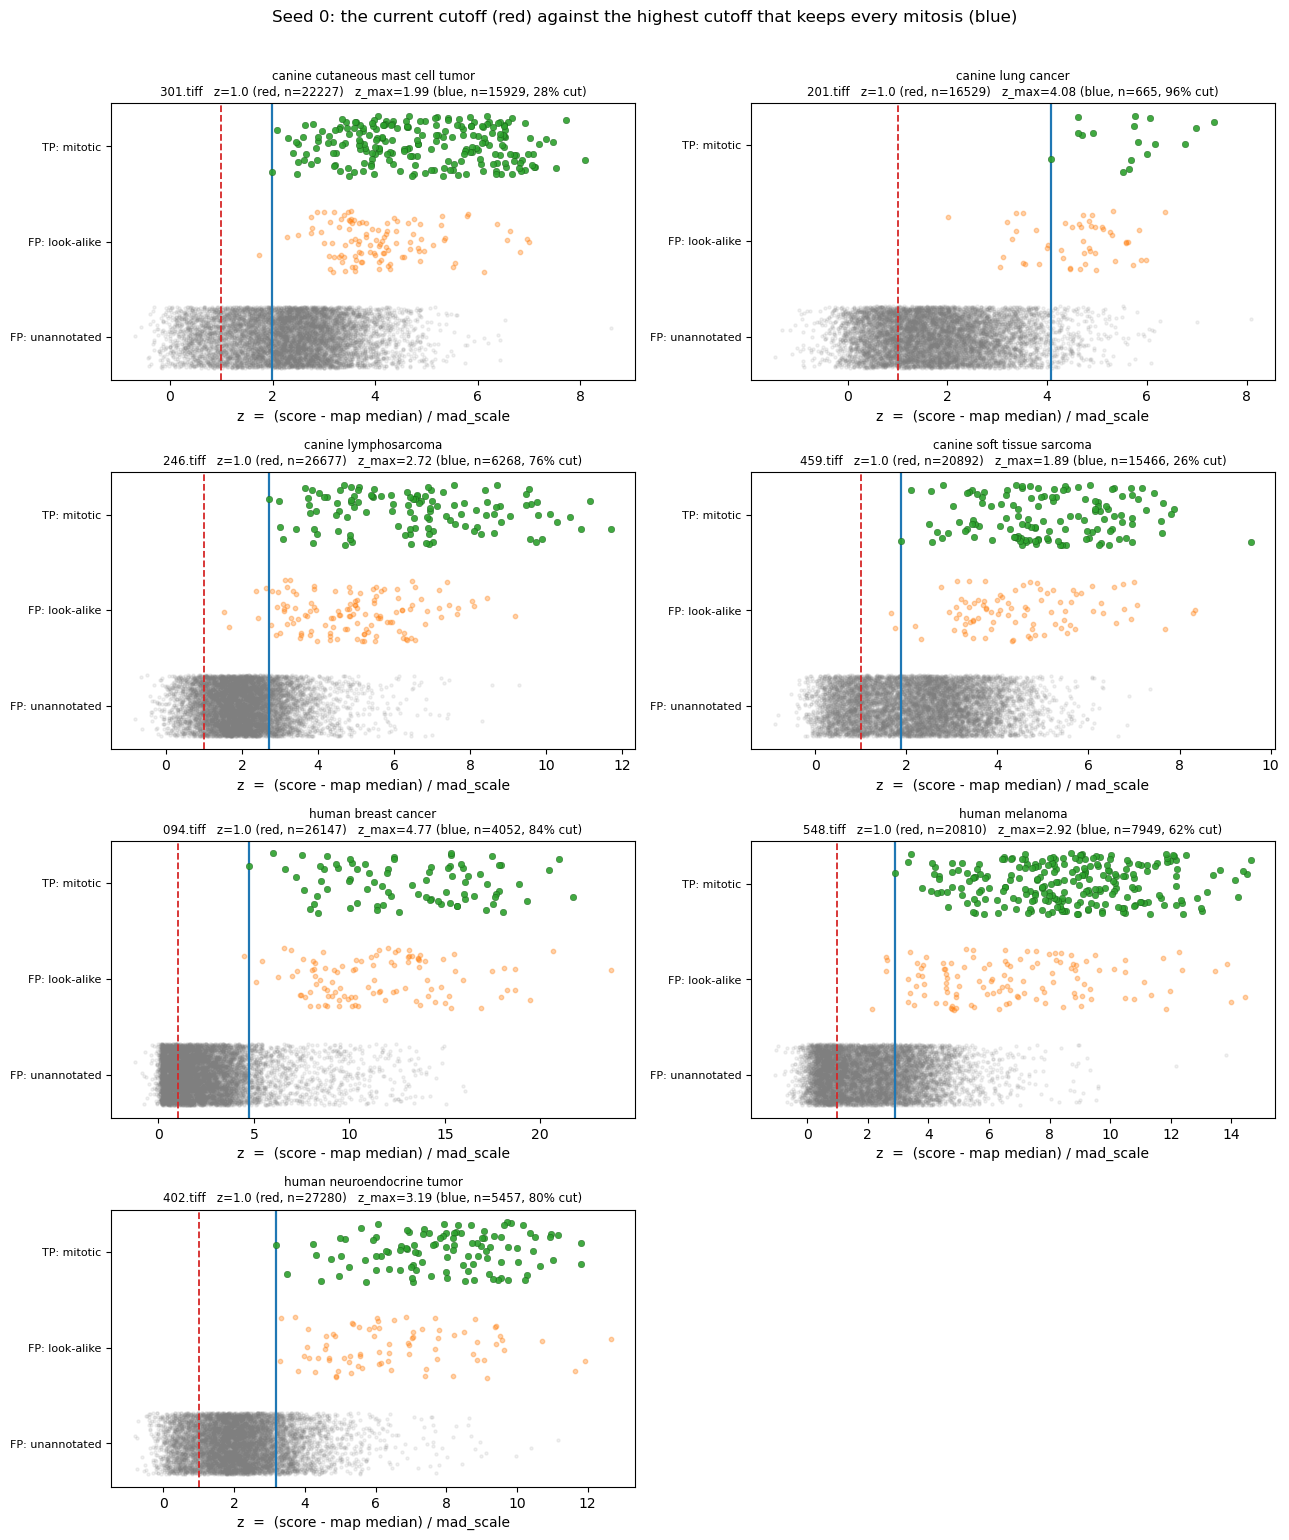

In [20]:
domains_by_file = domain_images.set_index('file_name')['tumor_type'].to_dict()
files = list(domain_images.sort_values('tumor_type')['file_name'])
n, ncols = len(files), 2
nrows = -(-n // ncols)
JITTER = 0.32
rng = np.random.default_rng(RNG_SEED)
fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.8 * nrows))
axes = np.atleast_1d(axes).ravel()

for ax, fn in zip(axes, files):
    det_out = pools[fn]
    for bucket in (ev.NON_HUMAN_FINDINGS, ev.HUMAN_REJECTED_LABEL, ev.HUMAN_CORRECT_LABEL):
        sub = det_out[det_out['bucket'] == bucket]
        if bucket == ev.NON_HUMAN_FINDINGS and len(sub) > FP_SUBSAMPLE_CAP:
            sub = sub.iloc[rng.choice(len(sub), size=FP_SUBSAMPLE_CAP, replace=False)]
        y = BUCKET_LANE[bucket] + rng.uniform(-JITTER, JITTER, size=len(sub))
        ax.scatter(sub['z'], y, color=BUCKET_COLOR[bucket], **STYLE[bucket])
    zm = float(s0.loc[fn, 'z_max'])
    ax.axvline(CURRENT_Z, color='#d62728', linestyle='--', linewidth=1.3)
    ax.axvline(zm, color='#1f77b4', linestyle='-', linewidth=1.6)
    ax.set_yticks([0, 1, 2])
    ax.set_yticklabels(['FP: unannotated', 'FP: look-alike', 'TP: mitotic'], fontsize=8)
    ax.set_xlabel('z  =  (score - map median) / mad_scale')
    ax.set_title(f"{domains_by_file[fn]}\n{fn}   z=1.0 (red, n={int(s0.loc[fn, 'n_at_current_z'])})"
                 f"   z_max={zm:.2f} (blue, n={int(s0.loc[fn, 'n_at_z_max'])}, "
                 f"{s0.loc[fn, 'pct_pool_cut']:.0f}% cut)", fontsize=8.5)
for ax in axes[n:]:
    ax.set_visible(False)
fig.suptitle('Seed 0: the current cutoff (red) against the highest cutoff that keeps every '
             'mitosis (blue)', y=1.01, fontsize=12)
fig.tight_layout()
plt.show()

## Closing summary

**The question, answered.** Yes -- and the notebook that raised it already contained the exact
answer. `full_list_recall` on the `tm_score` axis is a prefix statistic (the pool is
score-descending, the cut is a prefix, and `evaluate.greedy_match` on a prefix is the first *N*
steps of the full pass), so the highest cutoff preserving every mitosis is exactly the lowest
`z` among the deep pool's TP-bucketed detections. That is `tp_z_min`, which lcc's cell 38
computes and never prints.

**Read the cutoff, not the recall at it.** Full recall *at* `z_max` is true by construction --
`z_max` is defined as the lowest TP score -- so it carries no information, at any coverage.
Check 2 is a software check that the harness agrees with the identity, not a detector result.
The measurement is the **value** of `z_max`: how far above each response map's median the
worst-ranked mitosis sits.

**Headroom (seed 0, oracle).** Per-domain `z_max` runs **1.89 (soft tissue sarcoma) to 4.77
(breast cancer)** against the current 1.0, cutting **26-96% of the pool (median 76.5%)**.
Full-list precision -- the only full-list quantity that moves, since recall is pinned at 1.0 --
goes from 0.10-1.14% to 0.84-2.99% (1.4x-24.8x). It is a large relative gain on a very small
number, and it is not available at inference time.

**Deployable (worst over 5 seeds).** The worst cell is **z = 1.308** (`459.tiff`, seed 3)
against seed 0's own per-domain minimum of 1.891 -- a single-seed reading overstates the
globally safe cutoff by **0.58 z**. Evaluated at the deployable cutoffs rather than interpolated: a **global** cutoff (`z = 1.308`, shippable at 1 dp as **`z = 1.3`**) is worth a median **10%** of the candidate pool (7-14% by domain) and leaves coverage at **0.84-0.98**; a **per-domain** cutoff, still worst-click within its domain, is worth a median **39%** (9-80%) at coverage 0.26-0.96. The seed-0 oracle figure -- what a single-seed reading would have claimed -- was 62%. `results/f1_seed_sweep.csv`, an independent
execution of the same configuration, agrees with the closed form on **all 210 (ROI, seed, z)
cells** and independently shows `459.tiff` -- and only `459.tiff` -- losing a mitosis at
`z = 1.5` on 2 of its 5 seeds.

**Three reasons the deployable number is an upper bound, not a recommendation:**

* **It has no margin and has not converged.** The running minimum over seeds fell twice in five
  draws, most recently at k=4. Flat over the last two is not convergence. The in-domain margin
  analysis (what dropping 1-2 mitoses buys) is done at seed 0 on the oracle `z_max` and is
  never repeated at the deployable level, so the two halves of this notebook do not meet.
* **The ROI half of D4's rule is untested.** One ROI per domain here, and D4's stated reason
  for "worst ROI, worst click, per domain" is precisely that the ROIs cluster by tumour type.
* **It is still label-derived**, and 2 of the 35 draws are duplicate clicks (33 distinct), so
  the sample is slightly thinner than `n_seeds = 5` suggests.

**What raising the cutoff does not buy.** Measured row-wise across every non-truncated arm-row:
`recall_at_budget` on `tm_score` moved in **zero** cells, and of the `read_*` cells **zero**
changed value while 15 became `NaN`. The pool is read from the top; raising the floor deletes
the bottom. The one arm where the product metric moved at all was `chromatin_od`'s top-K, and
**re-measuring it at the deployable cutoffs removes almost all of that**. The +0.118 recall@100
headline is at the oracle `z_max`. Measured at the global cutoff the per-domain median gain is
**+0.0000 in all seven domains at recall@100** (it moves at all in only 3 of 35 (domain, seed)
cells) and at most +0.0046 at recall@250; at the per-domain cutoffs the largest median gain is
**+0.0174**. Note this had to be *measured*, not extrapolated: the `chromatin_od` arm's
`recall_at_budget` is not monotone in the cutoff (it goes slightly negative in one domain at
z = 2.5), so a value bracketed between two equal grid points is not thereby pinned. All of it
is non-decision-grade under D5 regardless.

**Coverage, read correctly.** It cannot upgrade the recall at `z_max`. Where it does bite is
the deployable cutoff, and there it is unflattering: at `z ~ 1.31` coverage is still high
enough that a full-recall claim on an unseen ROI would be substantially geometric. That is
reported in the deployable table rather than left out.

**What would make this a decision.** The same measurement on the 14 ROIs of
`images/extra_valid/` at 5 seeds drawn *without* replacement, read as D4 requires, with a
margin taken deliberately rather than inherited from a single worst cell -- and the margin
table put to a pathologist as the question it actually is: how many mitoses per ROI may the
candidate list miss. `DECISIONS.md` D4's closing note names the machinery (conformal risk
control) that turns "this cutoff kept everything on these seven ROIs" into a coverage
guarantee on an unseen slide.

**Two corrections to `tm_threshold_axis_sweep_largest_cc.ipynb`**, from
`Research Logs/2026-09-04-largest-cc-z-headroom-audit.md`: its closing summary's claim that
every `read_95_delta` is smaller than that ROI's own seed-to-seed SD is false for `459.tiff`
(+1416 vs 1199) and `402.tiff` (-1547 vs 593) when the two lists are joined on `file_name`
rather than compared as sets -- the same error appears in finding 5 of the 2026-09-03 audit
log, which is where it came from. The verdict it supports survives on the three seed-0 endpoint
hits. And its `pool_sorted` uses pandas' default unstable sort where `compare._rank` and
`extract_peaks` both document mergesort; fixed here.